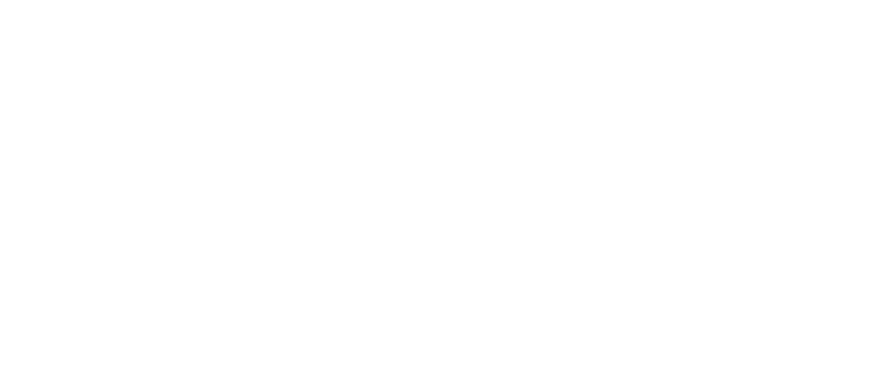

# Taller Introducción a la IA: DBScan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
sns.set(style="whitegrid")

In [3]:
X, y = make_blobs(n_samples=800,
                  centers=4,
                  cluster_std=[0.5, 0.1, 0.9, 0.35],
                  random_state=42)

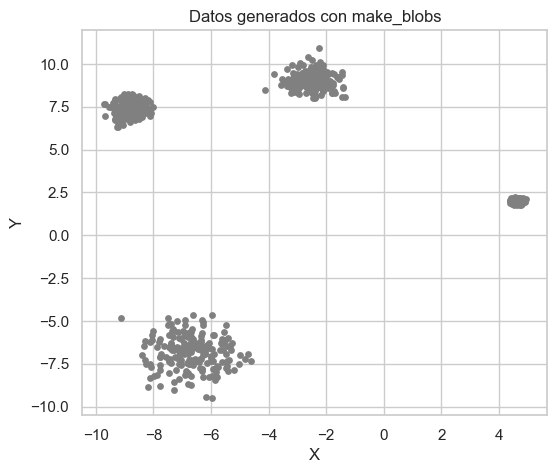

In [4]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=15, color='gray')
plt.title("Datos generados con make_blobs")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

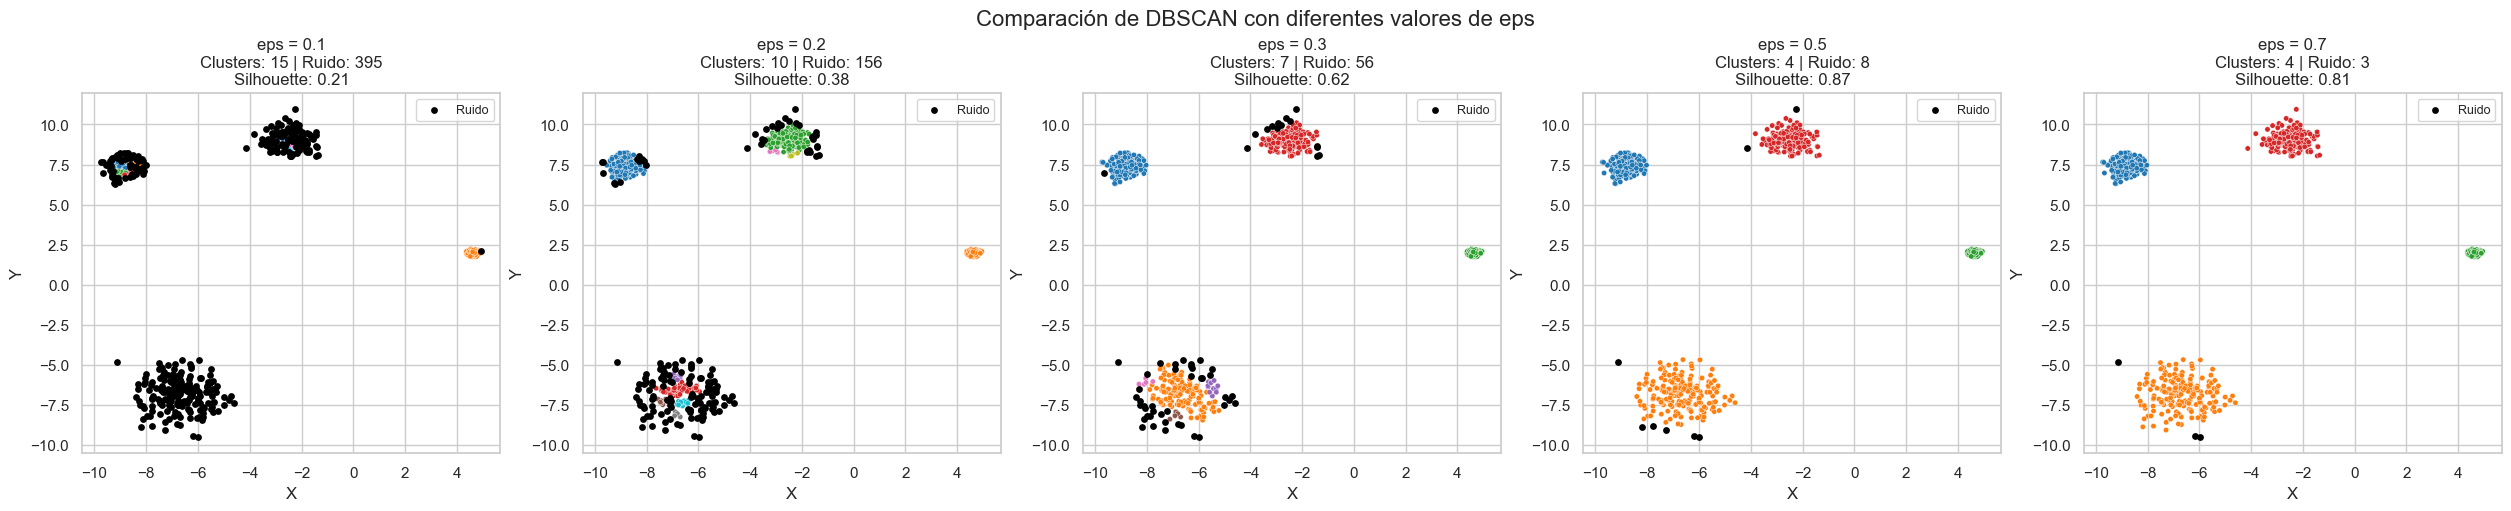

In [5]:
eps_values = [0.1, 0.2, 0.3, 0.5, 0.7]

best_score = -1
best_eps = None
best_labels = None

n_cols = len(eps_values)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5), constrained_layout=True)

for idx, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X)  # Completar: aplicar DBSCAN a los datos

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Completar: número de clústeres
    n_noise = sum(labels == -1)  # Completar: contar puntos de ruido

    if n_clusters > 1:
        score = silhouette_score(X, labels)  # Completar: calcular Silhouette Score
        if score > best_score:
            best_score = score
            best_eps = eps
            best_labels = labels
        score_text = f"Silhouette: {score:.2f}"
    else:
        score_text = "Silhouette: N/A"

    noise_mask = labels == -1  # Completar: máscara de ruido
    core_mask = labels != -1   # Completar: máscara de puntos de clúster

    ax = axes[idx]

    sns.scatterplot(x=X[core_mask][:, 0], y=X[core_mask][:, 1],
                    hue=labels[core_mask], palette='tab10', legend=False, s=15, ax=ax)

    ax.scatter(X[noise_mask][:, 0], X[noise_mask][:, 1],
               color='black', s=15, label='Ruido')

    ax.set_title(f"eps = {eps}\nClusters: {n_clusters} | Ruido: {n_noise}\n{score_text}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle("Comparación de DBSCAN con diferentes valores de eps", fontsize=16)
plt.show()



======= MEJOR CONFIGURACIÓN =======
Mejor eps: 0.5
Silhouette Score máximo: 0.866


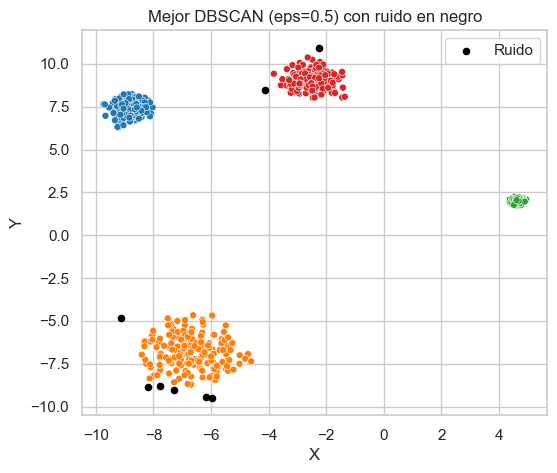

In [6]:
print("\n======= MEJOR CONFIGURACIÓN =======")
print(f"Mejor eps: {best_eps}")  # ← Completar: mejor valor de eps encontrado
print(f"Silhouette Score máximo: {best_score:.3f}")  # ← Completar: mejor score obtenido

plt.figure(figsize=(6, 5))
core_mask = best_labels != -1  # ← Completar: máscara para puntos del clúster

sns.scatterplot(x=X[core_mask][:, 0], y=X[core_mask][:, 1],
                hue=best_labels[core_mask], palette='tab10', s=25, legend=False)

plt.scatter(X[~core_mask][:, 0], X[~core_mask][:, 1],
            color='black', s=20, label='Ruido')

plt.title(f"Mejor DBSCAN (eps={best_eps}) con ruido en negro")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

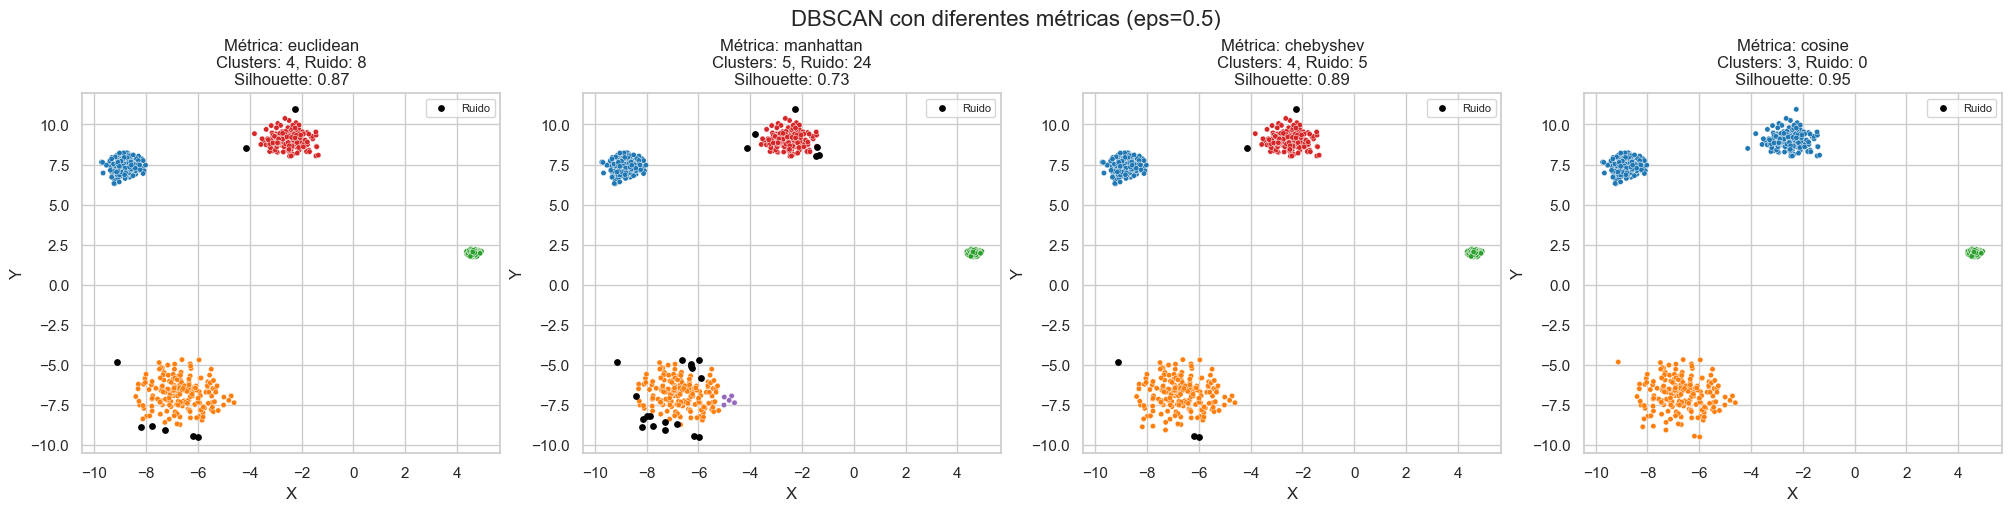

In [7]:
metrics = ['euclidean', 'manhattan', 'chebyshev', 'cosine']
eps = 0.5

results = []

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5), constrained_layout=True)

for idx, metric in enumerate(metrics):
    dbscan = DBSCAN(eps=eps, min_samples=5, metric=metric)
    labels = dbscan.fit_predict(X)  # ← Completar: aplicar DBSCAN con métrica

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # ← Completar: clústeres sin ruido
    n_noise = sum(labels == -1)  # ← Completar: cantidad de ruido

    if n_clusters > 1:
        score = silhouette_score(X, labels, metric=metric)  # ← Completar: Silhouette Score
        score_text = f"Silhouette: {score:.2f}"
    else:
        score = np.nan
        score_text = "Silhouette: N/A"

    results.append({
        'métrica': metric,
        'clusters': n_clusters,
        'ruido': n_noise,
        'silhouette_score': score
    })

    ax = axes[idx]
    noise_mask = labels == -1  # ← Completar: máscara de ruido
    core_mask = labels != -1   # ← Completar: máscara de clúster

    sns.scatterplot(x=X[core_mask][:, 0], y=X[core_mask][:, 1],
                    hue=labels[core_mask], palette='tab10', s=15, legend=False, ax=ax)

    ax.scatter(X[noise_mask][:, 0], X[noise_mask][:, 1],
               color='black', s=15, label='Ruido')

    ax.set_title(f"Métrica: {metric}\nClusters: {n_clusters}, Ruido: {n_noise}\n{score_text}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle(f"DBSCAN con diferentes métricas (eps={eps})", fontsize=16)
plt.show()


# **PREGUNTAS**

**1. ¿Cuál eps permitió obtener el mayor silhouette score?**  

la eps con valor 0.5

**2. ¿Cuántos clusters se obtuvieron usando el eps del punto anterior?**  

4 clusters

**3. ¿Qué sucede si el parámetro ε (epsilon) es demasiado pequeño o demasiado grande? ¿Cómo afecta esto a la cantidad de clústeres y al ruido?**  

un epsilon pequeño puede generar mas ruido  y mas clusters

**4. ¿Qué métrica de distancia produjo mejores resultados en DBSCAN según el Silhouette Score? ¿Consideras que en verdad fue el mejor resultado?**  

la mejor segun el silhouete fue la cosine, pero no se considera un buen resultado dado que agrupo dos grupos con una distancia notable en un solo cluster

**5. ¿Por qué DBSCAN es más adecuado que K-Means para detectar clústeres con formas no circulares o densidad variable?**  

dbscan no asume formas circulares mientras que means si lo hace, resultando en diferencias en la deteccion de ruido, ademas de que no necesita un k predefinido